# Decomposition, Stationarity, and Autocorrelation

Reads the cleaned dataset produced by `02_data_cleaning.ipynb` (`data/processed/demand_clean.csv`). Covers proposal.txt Sections 9.8-9.10: seasonal-trend decomposition (daily and weekly), stationarity testing (rolling statistics, ADF, KPSS) with differencing/log transforms, and autocorrelation analysis (ACF, PACF, lag correlation) -- the results here motivate the SARIMA order used in `07_statistical_models.ipynb` and the lag features used in `05_feature_engineering.ipynb`.

In [1]:
import os
import sys
from pathlib import Path

import yaml

# Works both in the local repo and on Kaggle. Locally, config.yaml is read
# from disk. On Kaggle there is no repo checkout -- only whatever cells you
# paste -- so the config is built inline instead. This notebook only reads
# from /kaggle/working (produced by 02_data_cleaning.ipynb earlier in the
# same Kaggle session), never from /kaggle/input, so IS_KAGGLE just needs
# KAGGLE_KERNEL_RUN_TYPE (always set on Kaggle) -- no dataset needs to be
# attached for this notebook specifically.
IS_KAGGLE = "KAGGLE_KERNEL_RUN_TYPE" in os.environ

if IS_KAGGLE:
    REPO_ROOT = Path("/kaggle/working")
    config = {
        "data": {
            "processed_file": "/kaggle/working/data/processed/demand_clean.csv",
            "timestamp_col": "timestamp",
            "target_col": "demand",
            "frequency": "h",
        },
        "features": {"lags": [1, 2, 6, 24, 48, 168]},
    }
else:
    def find_repo_root(start: Path) -> Path:
        for parent in [start, *start.parents]:
            if (parent / "config.yaml").exists():
                return parent
        raise FileNotFoundError("config.yaml not found in any parent directory")

    REPO_ROOT = find_repo_root(Path.cwd())
    sys.path.insert(0, str(REPO_ROOT))

    with open(REPO_ROOT / "config.yaml") as f:
        config = yaml.safe_load(f)

config

{'data': {'raw_path': 'data/raw/',
  'processed_path': 'data/processed/',
  'processed_file': 'data/processed/demand_clean.csv',
  'features_file': 'data/processed/features.csv',
  'timestamp_col': 'timestamp',
  'target_col': 'demand',
  'frequency': 'h'},
 'split': {'train_ratio': 0.7, 'val_ratio': 0.15, 'test_ratio': 0.15},
 'features': {'lags': [1, 2, 6, 24, 48, 168],
  'rolling_windows': [3, 6, 12, 24, 168],
  'cyclical': ['hour', 'day_of_week', 'month']},
 'lstm': {'sequence_length': 24,
  'units': 64,
  'layers': 1,
  'dropout': 0.2,
  'batch_size': 32,
  'learning_rate': 0.001,
  'epochs': 50,
  'early_stopping_patience': 5},
 'peak_demand': {'percentile_threshold': 0.95, 'seasonal': True},
 'models': {'xgboost_path': 'models/xgboost_model.pkl',
  'xgboost_feature_columns': 'models/xgboost_feature_columns.json',
  'sarima_path': 'models/sarima_model.pkl',
  'lstm_path': 'models/lstm_model.h5',
  'lstm_scaler_path': 'models/lstm_scaler.pkl',
  'lstm_feature_columns': 'models/lst

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller, kpss

# Same Kaggle-vs-local split as notebook 02 -- see that notebook's note.
if IS_KAGGLE:
    def load_raw_data(path, timestamp_col="timestamp"):
        df = pd.read_csv(path, parse_dates=[timestamp_col])
        return df.sort_values(timestamp_col).reset_index(drop=True)

    def set_timestamp_index(df, timestamp_col="timestamp"):
        df = df.set_index(timestamp_col)
        return df.sort_index()
else:
    from src.data.load_data import load_raw_data, set_timestamp_index

PROCESSED_PATH = REPO_ROOT / config["data"]["processed_file"]
TIMESTAMP_COL = config["data"]["timestamp_col"]
TARGET_COL = config["data"]["target_col"]
LAGS = config["features"]["lags"]

DAILY_PERIOD = 24
WEEKLY_PERIOD = 24 * 7

sns.set_theme(style="whitegrid")

## Load the cleaned dataset

In [3]:
df = load_raw_data(PROCESSED_PATH, TIMESTAMP_COL)
df = set_timestamp_index(df, TIMESTAMP_COL)

demand = df[TARGET_COL]
print(f"{len(demand)} hourly observations, {demand.isna().sum()} missing")
demand.head()

47472 hourly observations, 0 missing


timestamp
2020-01-01 00:00:00    1626.458412
2020-01-01 01:00:00    1593.917861
2020-01-01 02:00:00    1457.196911
2020-01-01 03:00:00    1302.073833
2020-01-01 04:00:00    1349.054422
Name: demand, dtype: float64

## Time series decomposition

STL (Seasonal-Trend decomposition using LOESS) splits demand into trend, seasonal, and residual components. Run twice: once with a 24-hour (daily) period and once with a 168-hour (weekly) period, since both cycles are visible in the EDA notebook's hourly and day-of-week plots.

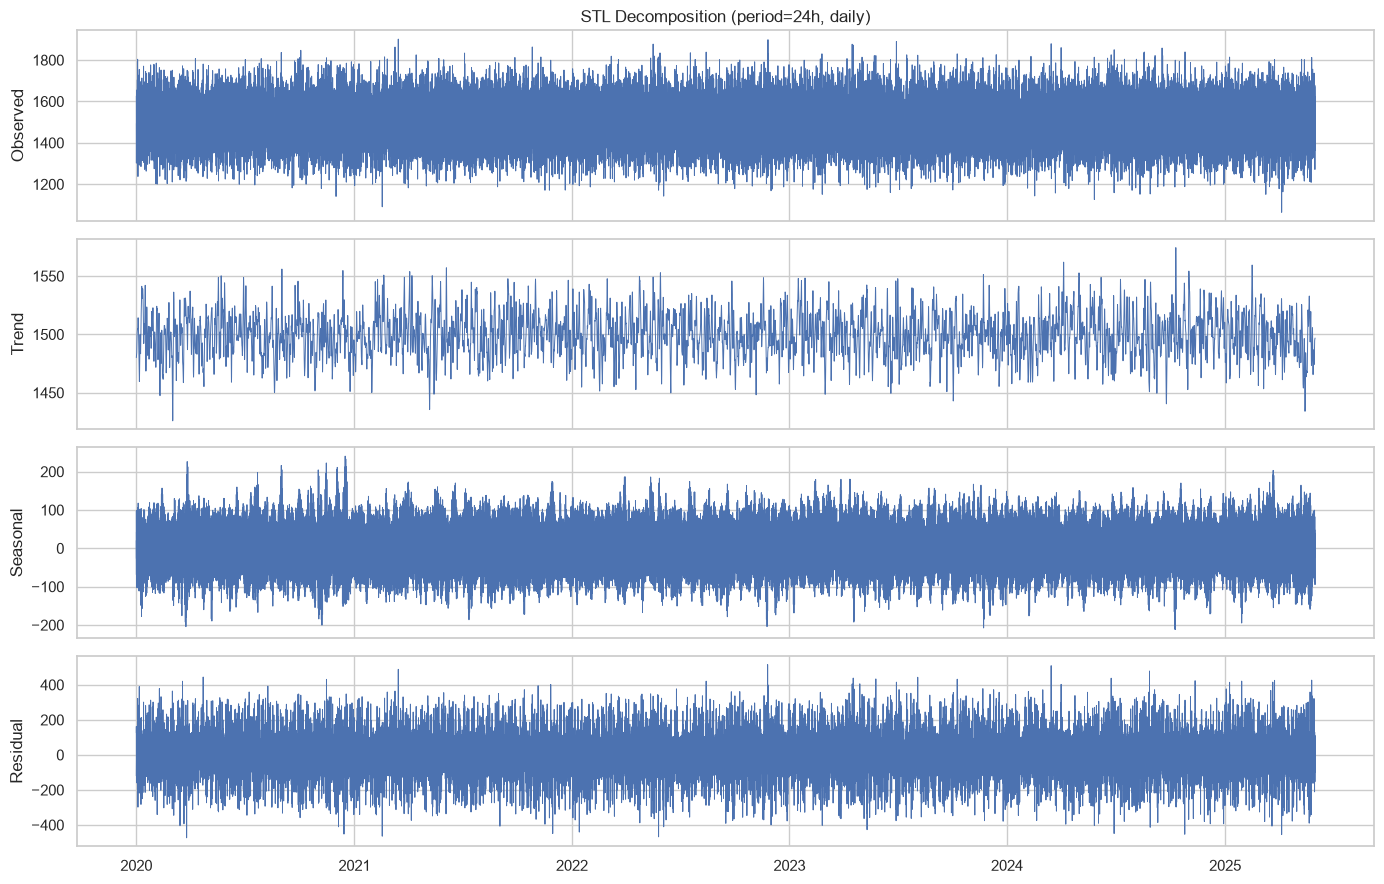

In [4]:
def plot_stl(result, title):
    fig, axes = plt.subplots(4, 1, figsize=(14, 9), sharex=True)
    for ax, comp, label in zip(
        axes,
        [result.observed, result.trend, result.seasonal, result.resid],
        ["Observed", "Trend", "Seasonal", "Residual"],
    ):
        ax.plot(comp.index, comp.values, linewidth=0.7)
        ax.set_ylabel(label)
    axes[0].set_title(title)
    plt.tight_layout()
    plt.show()


daily_stl = STL(demand, period=DAILY_PERIOD, robust=True).fit()
plot_stl(daily_stl, f"STL Decomposition (period={DAILY_PERIOD}h, daily)")

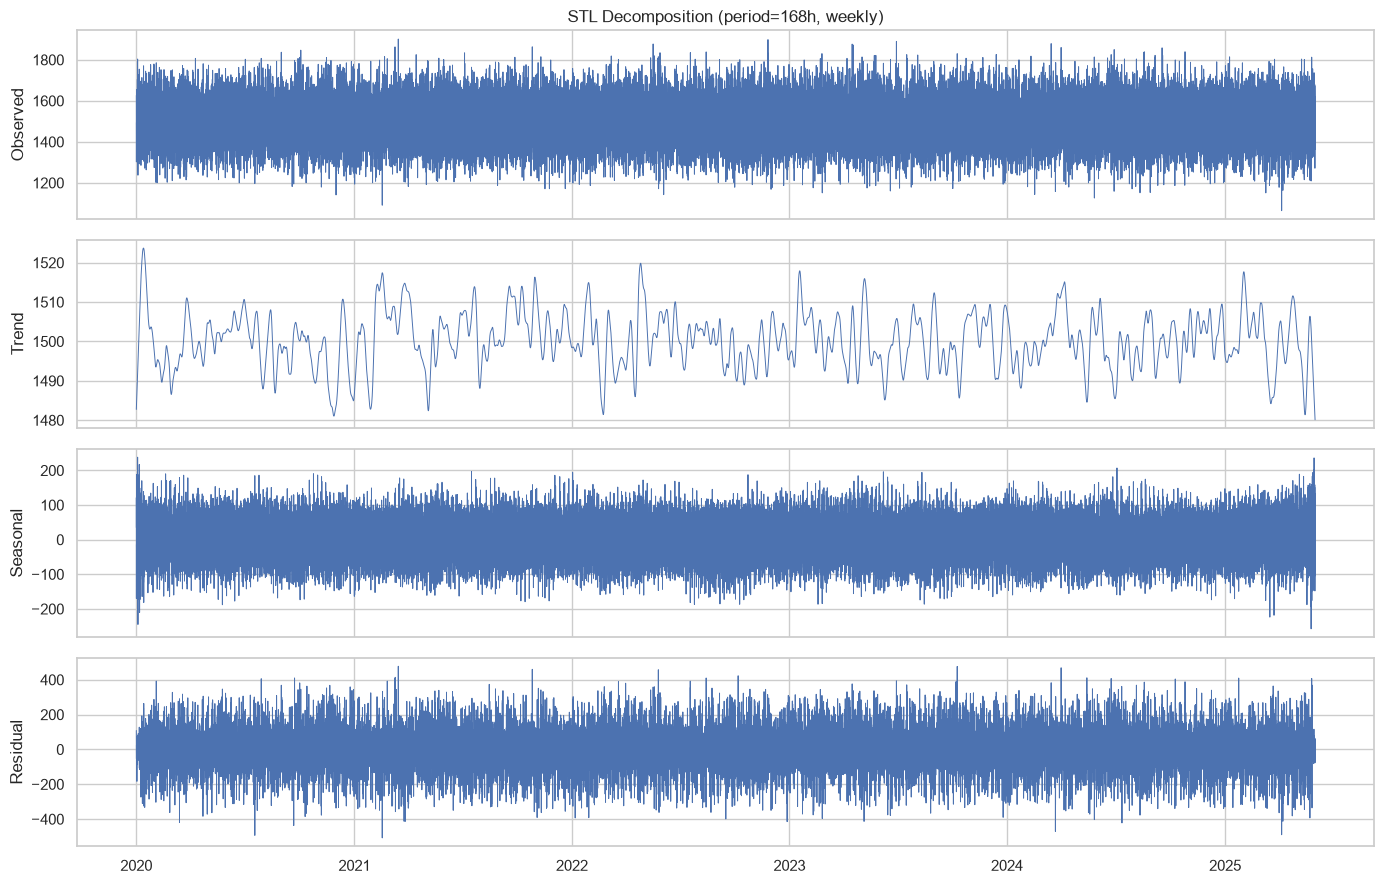

In [5]:
weekly_stl = STL(demand, period=WEEKLY_PERIOD, robust=True).fit()
plot_stl(weekly_stl, f"STL Decomposition (period={WEEKLY_PERIOD}h, weekly)")

## Rolling mean and variance

A weekly (168-hour) rolling window smooths out the daily cycle so any longer-term drift in level or spread is easier to see.

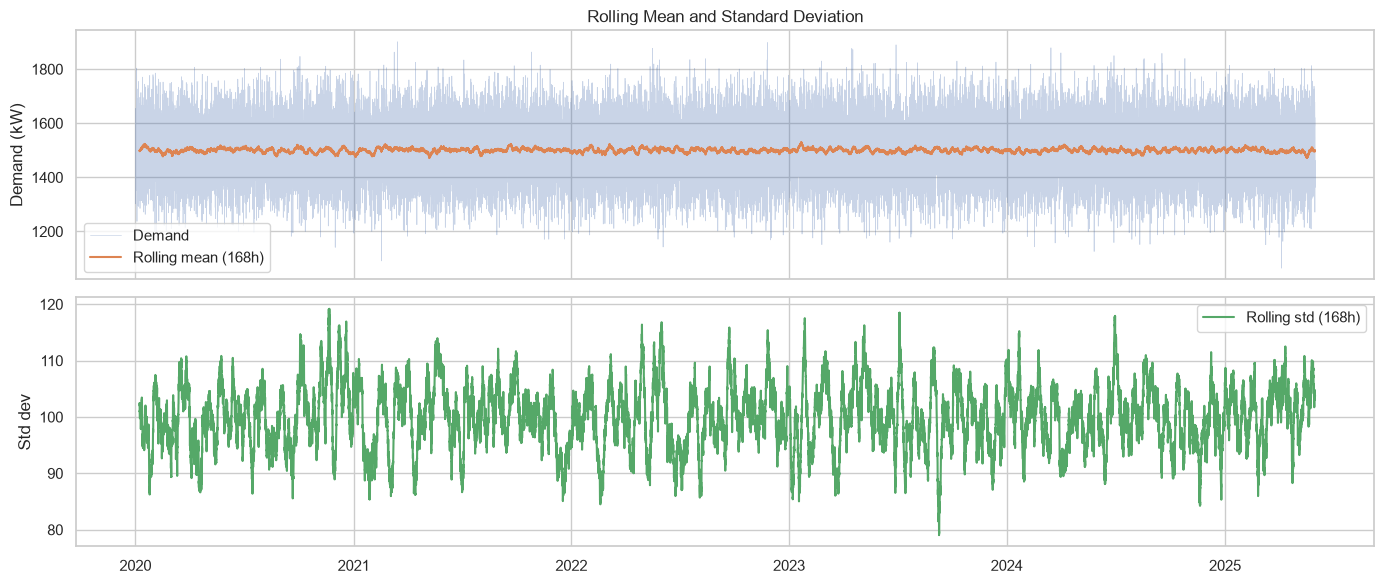

In [6]:
rolling_mean = demand.rolling(window=WEEKLY_PERIOD).mean()
rolling_std = demand.rolling(window=WEEKLY_PERIOD).std()

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
axes[0].plot(demand.index, demand.values, alpha=0.3, linewidth=0.5, label="Demand")
axes[0].plot(rolling_mean.index, rolling_mean.values, color="C1", label="Rolling mean (168h)")
axes[0].set_ylabel("Demand (kW)")
axes[0].legend()
axes[1].plot(rolling_std.index, rolling_std.values, color="C2", label="Rolling std (168h)")
axes[1].set_ylabel("Std dev")
axes[1].legend()
axes[0].set_title("Rolling Mean and Standard Deviation")
plt.tight_layout()
plt.show()

## Stationarity tests: ADF and KPSS

The two tests have opposite null hypotheses, so they're read together:
- **ADF** null = series has a unit root (non-stationary). A small p-value (< 0.05) rejects this, i.e. supports stationarity.
- **KPSS** null = series is stationary. A small p-value (< 0.05) rejects this, i.e. supports non-stationarity.

In [7]:
def stationarity_summary(series, label):
    series = series.dropna()
    adf_stat, adf_p, *_ = adfuller(series, autolag="AIC")
    kpss_stat, kpss_p, *_ = kpss(series, regression="c", nlags="auto")
    return {
        "series": label,
        "adf_stat": adf_stat,
        "adf_p": adf_p,
        "adf_stationary": adf_p < 0.05,
        "kpss_stat": kpss_stat,
        "kpss_p": kpss_p,
        "kpss_stationary": kpss_p >= 0.05,
    }


log_demand = np.log1p(demand)
diff1 = demand.diff()
seasonal_diff = demand.diff(DAILY_PERIOD)

results = pd.DataFrame(
    [
        stationarity_summary(demand, "level"),
        stationarity_summary(log_demand, "log"),
        stationarity_summary(diff1, "first difference"),
        stationarity_summary(seasonal_diff, f"seasonal difference ({DAILY_PERIOD}h)"),
    ]
).set_index("series")
results

C:\Users\ashin\AppData\Local\Temp\ipykernel_4720\3198053761.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(series, regression="c", nlags="auto")


C:\Users\ashin\AppData\Local\Temp\ipykernel_4720\3198053761.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(series, regression="c", nlags="auto")


C:\Users\ashin\AppData\Local\Temp\ipykernel_4720\3198053761.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(series, regression="c", nlags="auto")


C:\Users\ashin\AppData\Local\Temp\ipykernel_4720\3198053761.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(series, regression="c", nlags="auto")


,adf_stat,adf_p,adf_stationary,kpss_stat,kpss_p,kpss_stationary
series,,,,,,
level,-217.536068,0.0,True,0.047614,0.1,True
log,-217.530538,0.0,True,0.049503,0.1,True
first difference,-49.767140,0.0,True,0.105788,0.1,True
seasonal difference (24h),-55.181381,0.0,True,0.000404,0.1,True


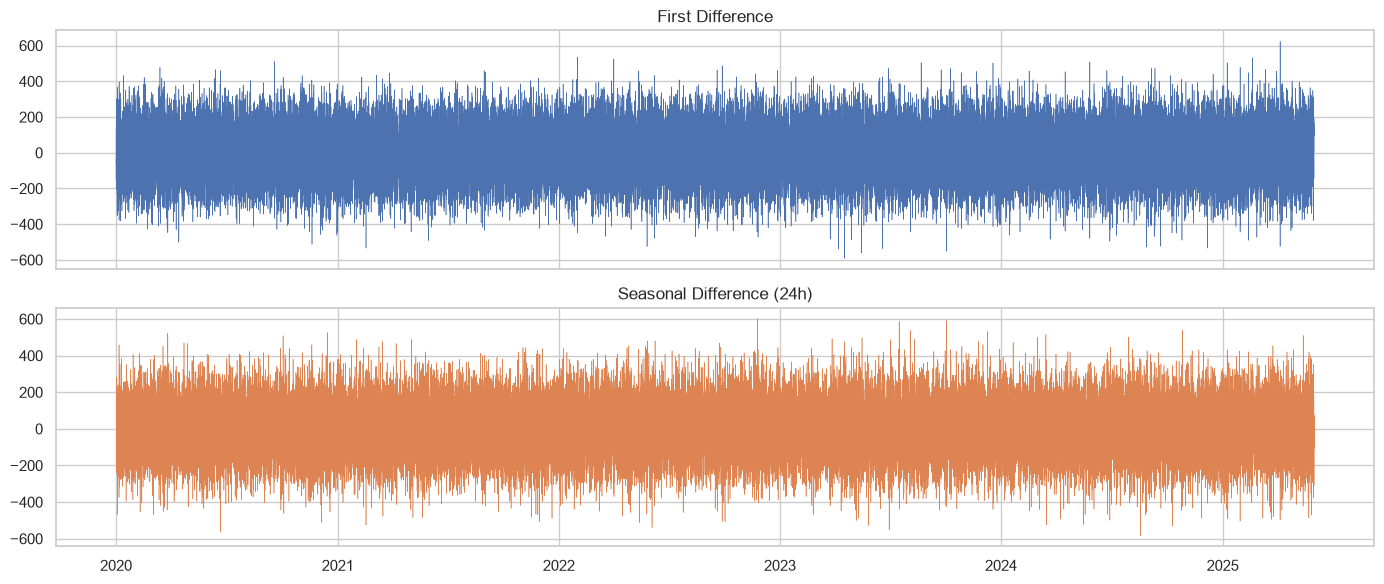

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
axes[0].plot(diff1.index, diff1.values, linewidth=0.4)
axes[0].set_title("First Difference")
axes[1].plot(seasonal_diff.index, seasonal_diff.values, linewidth=0.4, color="C1")
axes[1].set_title(f"Seasonal Difference ({DAILY_PERIOD}h)")
plt.tight_layout()
plt.show()

## Autocorrelation and partial autocorrelation

ACF/PACF on the seasonally-differenced series (removes the dominant 24-hour cycle so shorter-lag AR/MA structure is visible) -- this is what motivates the non-seasonal `(p, d, q)` order used for SARIMA in `07_statistical_models.ipynb`. Lags shown out to 72h (3 days) to also confirm the daily cycle spikes at multiples of 24.

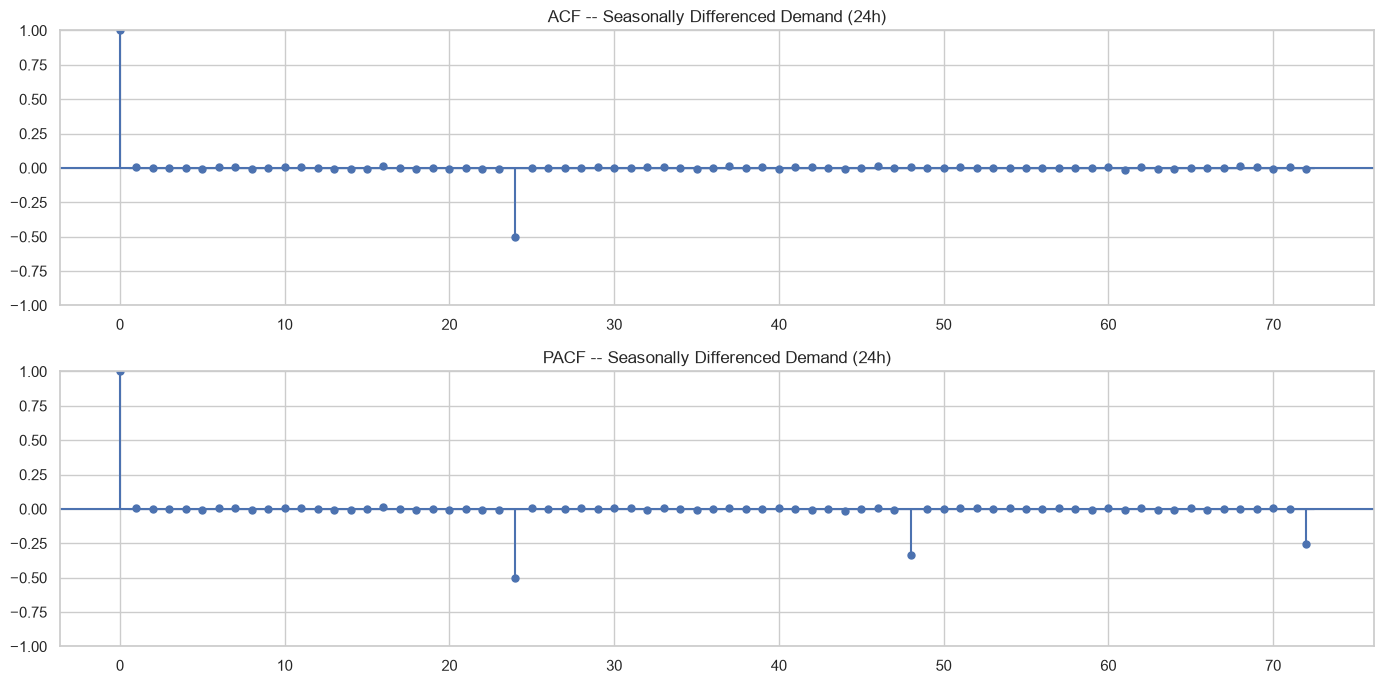

In [9]:
seasonal_diff_clean = seasonal_diff.dropna()

fig, axes = plt.subplots(2, 1, figsize=(14, 7))
plot_acf(seasonal_diff_clean, lags=72, ax=axes[0])
axes[0].set_title(f"ACF -- Seasonally Differenced Demand ({DAILY_PERIOD}h)")
plot_pacf(seasonal_diff_clean, lags=72, ax=axes[1], method="ywm")
axes[1].set_title(f"PACF -- Seasonally Differenced Demand ({DAILY_PERIOD}h)")
plt.tight_layout()
plt.show()

## Lag correlation analysis

Pearson correlation between demand and its own lagged values at the specific lags used for feature engineering (`config.yaml: features.lags`), on the raw (undifferenced) series -- this checks that each configured lag actually carries predictive signal.

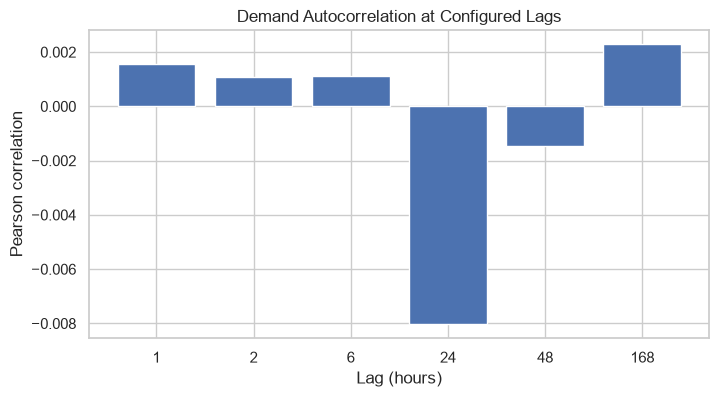

lag (hours)
1      0.001553
2      0.001094
6      0.001135
24    -0.008032
48    -0.001445
168    0.002287
Name: correlation, dtype: float64

In [10]:
lag_corr = pd.Series(
    {lag: demand.corr(demand.shift(lag)) for lag in LAGS},
    name="correlation",
)
lag_corr.index.name = "lag (hours)"

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(lag_corr.index.astype(str), lag_corr.values)
ax.set_title("Demand Autocorrelation at Configured Lags")
ax.set_xlabel("Lag (hours)")
ax.set_ylabel("Pearson correlation")
plt.show()

lag_corr